In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.set_style("whitegrid")

<Figure size 800x500 with 0 Axes>

In [2]:
from google.colab import files

uploaded = files.upload()

Saving retail_sales_dataset.csv to retail_sales_dataset (1).csv


In [3]:
df = pd.read_csv('retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Shape: (1000, 9)

Columns:
Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [5]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


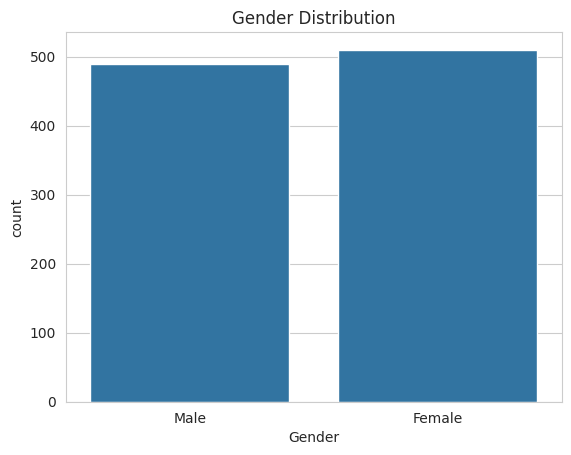

In [9]:
sns.countplot(data=df, x='Gender')

plt.title("Gender Distribution")
plt.show()

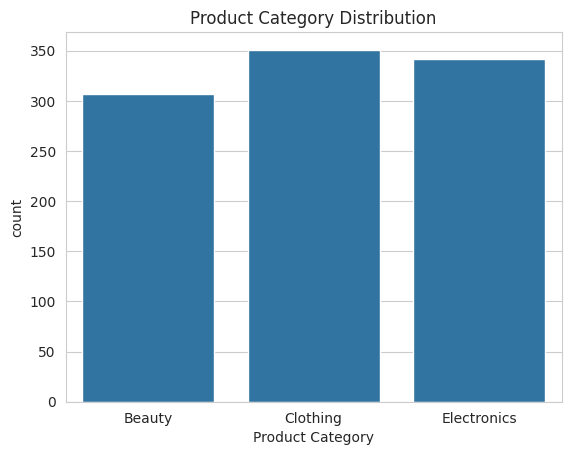

In [10]:
sns.countplot(data=df, x='Product Category')

plt.title("Product Category Distribution")
plt.show()

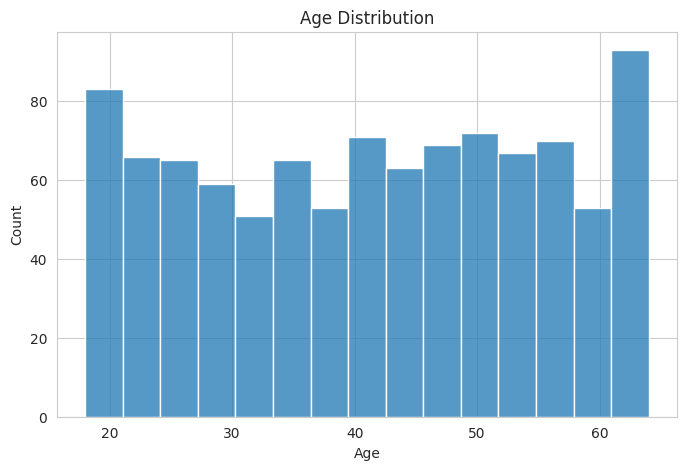

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=15)

plt.title("Age Distribution")
plt.show()

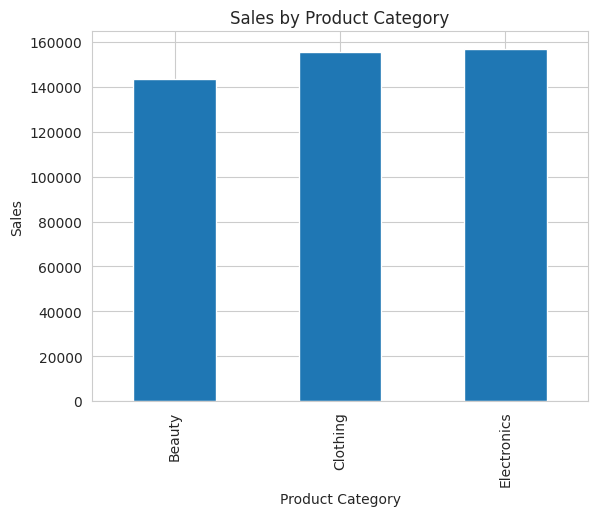

In [12]:
sales_by_category = df.groupby(
    'Product Category'
)['Total Amount'].sum()

sales_by_category.plot(kind='bar')

plt.title("Sales by Product Category")
plt.ylabel("Sales")
plt.show()

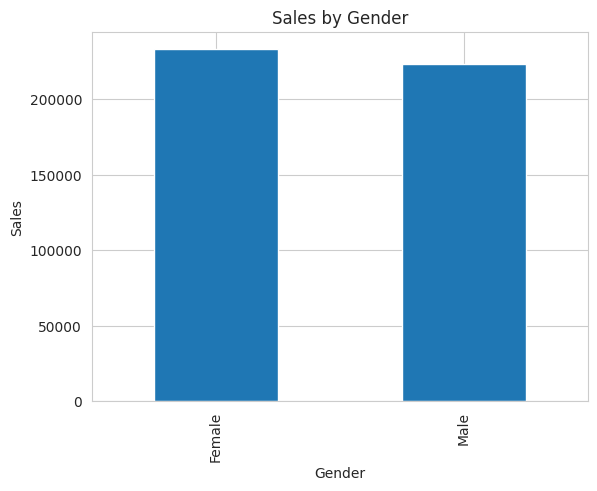

In [13]:
gender_sales = df.groupby(
    'Gender'
)['Total Amount'].sum()

gender_sales.plot(kind='bar')

plt.title("Sales by Gender")
plt.ylabel("Sales")
plt.show()

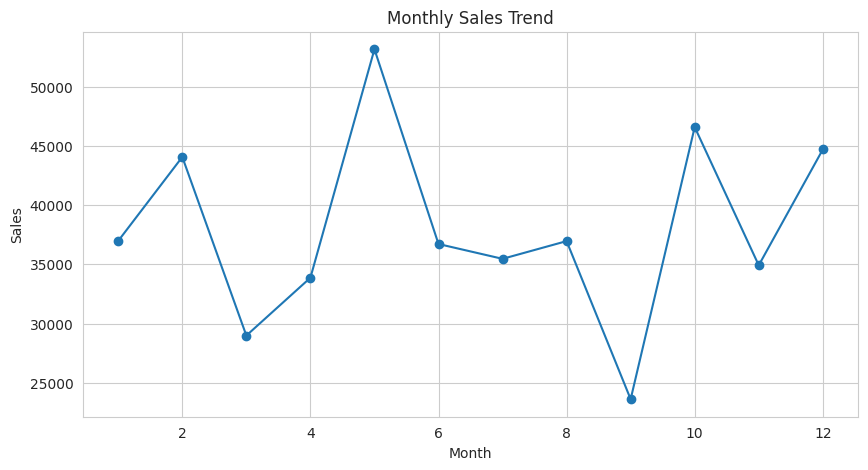

In [14]:
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby(
    'Month'
)['Total Amount'].sum()

monthly_sales.plot(
    marker='o',
    figsize=(10,5)
)

plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

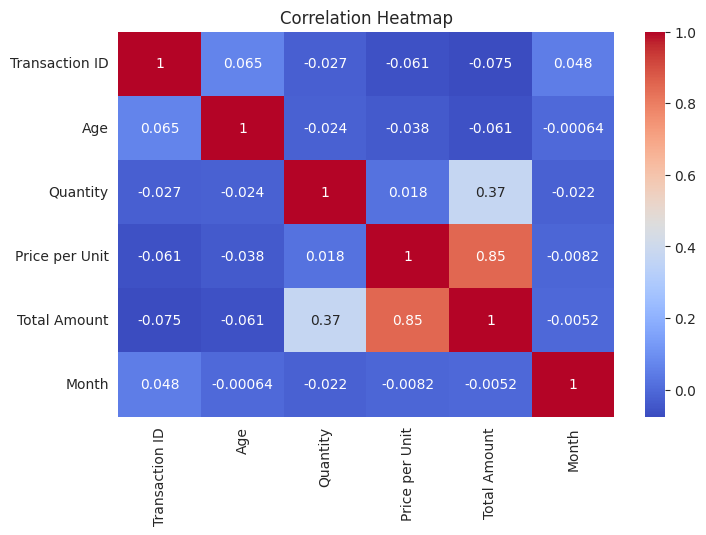

In [15]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
top_customers = df.groupby(
    'Customer ID'
)['Total Amount'].sum().sort_values(
    ascending=False
)

top_customers.head(10)

,Total Amount
Customer ID,
CUST015,2000
CUST412,2000
CUST970,2000
CUST547,2000
CUST281,2000
CUST416,2000
CUST420,2000
CUST927,2000
CUST447,2000


/tmp/ipykernel_1432/2796664785.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_sales = df.groupby(


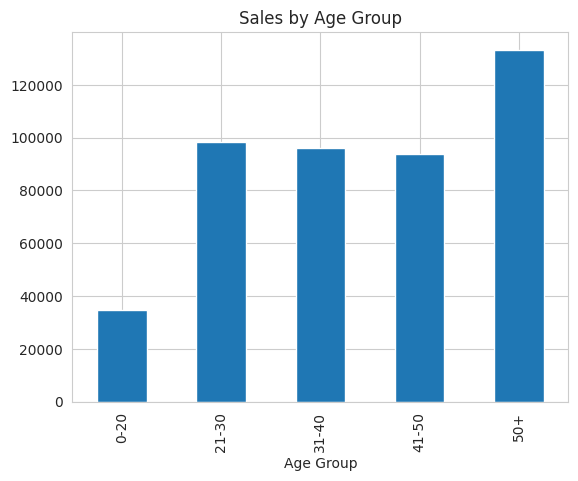

In [17]:
bins = [0,20,30,40,50,100]

labels = [
    '0-20',
    '21-30',
    '31-40',
    '41-50',
    '50+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

age_sales = df.groupby(
    'Age Group'
)['Total Amount'].sum()

age_sales.plot(kind='bar')

plt.title("Sales by Age Group")
plt.show()